In [4]:
!pip install opencv-python


   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ------- -------------------------------- 6.8/38.8 MB 38.1 MB/s eta 0:00:01
   ------------------ --------------------- 17.6/38.8 MB 42.5 MB/s eta 0:00:01
   --------------------------- ------------ 26.7/38.8 MB 42.4 MB/s eta 0:00:01
   ------------------------------------ --- 35.7/38.8 MB 42.7 MB/s eta 0:00:01
   ---------------------------------------- 38.8/38.8 MB 38.6 MB/s eta 0:00:00


In [6]:
!pip install object-detection


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 26.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 40.2 MB/s eta 0:00:00


In [2]:
import tensorflow as tf # Machine learning library
from tensorflow import keras # Library for neural networks
import numpy as np # Scientific computing library
import cv2 # Computer vision library
import glob # Filename handling library
import collections # Handles specialized container datatypes
import matplotlib.pyplot as plt # Plotting library
import object_detection # Custom object detection program
import sys
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, Adadelta
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical


To detect objects, we will use a pretrained neural network that has been trained on the COCO data set. You can read more about this data set here: https://content.alegion.com/datasets/coco-ms-coco-dataset
COCO labels are here: https://github.com/tensorflow/models/blob/master/research/object_detection/data/mscoco_label_map.pbtxt

In [3]:
LABEL_PERSON = 1
LABEL_CAR = 3
LABEL_BUS = 6
LABEL_TRUCK = 8
LABEL_TRAFFIC_LIGHT = 10
LABEL_STOP_SIGN = 13


**Eliminate Duplicate Bounding Boxes**

In [4]:
def accept_box(boxes, box_index, tolerance):
  box = boxes[box_index]
 
  for idx in range(box_index):
    other_box = boxes[idx]
    if abs(center(other_box, "x") - center(box, "x")) < tolerance and abs(center(other_box, "y") - center(box, "y")) < tolerance:
      return False
 
  return True


**Create List For All Directory Images**

In [5]:
def get_files(pattern):
  files = []
 
  # For each file that matches the specified pattern
  for file_name in glob.iglob(pattern, recursive=True):
 
    # Add the image file to the list of files
    files.append(file_name)
 
  # Return the complete file list
  return files


**Download Pretrained Object Detection Model**

In [6]:
def load_model(model_name):
  url = 'http://download.tensorflow.org/models/object_detection/tf2/20200711/' + model_name + '.tar.gz'
     
  # Download a file from a URL that is not already in the cache
  model_dir = tf.keras.utils.get_file(fname=model_name, untar=True, origin=url)
 
  print("Model path: ", str(model_dir))
   
  model_dir = str(model_dir) + "/saved_model"
  model = tf.saved_model.load(str(model_dir))
 
  return model


**Load Image in RGB Format**

In [7]:
def load_rgb_images(pattern, shape=None):
  # Get a list of all the image files in a directory
  files = get_files(pattern)
 
  # For each image in the directory, convert it from BGR format to RGB format
  images = [cv2.cvtColor(cv2.imread(file), cv2.COLOR_BGR2RGB) for file in files]
 
  # Resize the image if the desired shape is provided
  if shape:
    return [cv2.resize(img, shape) for img in images]
  else:
    return images


**Load Neural Network With SSD Architecture Trained on COCO Dataset**

In [8]:
def load_ssd_coco():
  return load_model("ssd_resnet50_v1_fpn_640x640_coco17_tpu-8")


**Annotate Images With Object Types**

In [10]:
def save_image_annotated(img_rgb, file_name, output, model_traffic_lights=None):
  # Create annotated image file 
  output_file = file_name.replace('.jpg', '_test.jpg')
     
  # For each bounding box that was detected  
  for idx in range(len(output['boxes'])):
 
    # Extract the type of the object that was detected
    obj_class = output["detection_classes"][idx]
     
    # How confident the object detection model is on the object's type
    score = int(output["detection_scores"][idx] * 100)

    if score >= 28 :
      # Extract the bounding box
      box = output["boxes"][idx]
  
      color = None
      label_text = ""

      if obj_class == LABEL_PERSON:
        color = (0, 255, 255)
        label_text = "Person " + str(score)

      if obj_class == LABEL_CAR:
        color = (255, 255, 0)
        label_text = "Car " + str(score)

      if obj_class == LABEL_BUS:
        color = (255, 255, 0)
        label_text = "Bus " + str(score)

      if obj_class == LABEL_TRUCK:
        color = (255, 255, 0)
        label_text = "Truck " + str(score)
        
      
      if obj_class == LABEL_STOP_SIGN:
        color = (128, 0, 0)
        label_text = "Stop Sign " + str(score)
      if obj_class == LABEL_TRAFFIC_LIGHT:
        color = (255, 255, 255)
        label_text = "Traffic Light " + str(score)
              
        if model_traffic_lights:
                # Annotate the image and save it
          img_traffic_light = img_rgb[box["y"]:box["y2"], box["x"]:box["x2"]]
          img_inception = cv2.resize(img_traffic_light, (299, 299))
          
                  # Uncomment this if you want to save a cropped image of the traffic light
          #cv2.imwrite(output_file.replace('.jpg', '_crop.jpg'), cv2.cvtColor(img_inception, cv2.COLOR_RGB2BGR))
          img_inception = np.array([preprocess_input(img_inception)])
  
          prediction = model_traffic_lights.predict(img_inception)
          label = np.argmax(prediction)
          score_light = str(int(np.max(prediction) * 100))
          if label == 0:
            label_text = "Green " + score_light
          elif label == 1:
            label_text = "Yellow " + score_light
          elif label == 2:
            label_text = "Red " + score_light
          else:
            label_text = 'NO-LIGHT'  # This is not a traffic light
      
      if color and label_text and accept_box(output["boxes"], idx, 5.0) :
        cv2.rectangle(img_rgb, (box["x"], box["y"]), (box["x2"], box["y2"]), color, 2)
        cv2.putText(img_rgb, label_text, (box["x"], box["y"]), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
  
    cv2.imwrite(output_file, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))


**Get Bounding Box Center**

In [11]:
def center(box, coord_type):
  return (box[coord_type] + box[coord_type + "2"]) / 2


**Perform Image Object Detection Using Predefined Neural Network**

In [12]:
def perform_object_detection(model, file_name, save_annotated=False, model_traffic_lights=None):
  # Store the image
  img_bgr = cv2.imread(file_name)
  img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
  input_tensor = tf.convert_to_tensor(img_rgb) # Input needs to be a tensor
  input_tensor = input_tensor[tf.newaxis, ...]
 
  # Run the model
  output = model(input_tensor)
 
  print("num_detections:", output['num_detections'], int(output['num_detections']))
 
  # Convert the tensors to a NumPy array
  num_detections = int(output.pop('num_detections'))
  output = {key: value[0, :num_detections].numpy()
            for key, value in output.items()}
  output['num_detections'] = num_detections
 
  # The detected classes need to be integers.
  output['detection_classes'] = output['detection_classes'].astype(np.int64)
  output['boxes'] = [
    {"y": int(box[0] * img_rgb.shape[0]), "x": int(box[1] * img_rgb.shape[1]), "y2": int(box[2] * img_rgb.shape[0]),
     "x2": int(box[3] * img_rgb.shape[1])} for box in output['detection_boxes']]
 
  if save_annotated:
    save_image_annotated(img_rgb, file_name, output, model_traffic_lights)
 
  return img_rgb, output, file_name


**Perform Video Object Detection Using Predefined Neural Network**

In [13]:
def perform_object_detection_video(model, video_frame, model_traffic_lights=None):
  # Store the image
  img_rgb = cv2.cvtColor(video_frame, cv2.COLOR_BGR2RGB)
  input_tensor = tf.convert_to_tensor(img_rgb) # Input needs to be a tensor
  input_tensor = input_tensor[tf.newaxis, ...]
 
  # Run the model
  output = model(input_tensor)
 
  # Convert the tensors to a NumPy array
  num_detections = int(output.pop('num_detections'))
  output = {key: value[0, :num_detections].numpy()
            for key, value in output.items()}
  output['num_detections'] = num_detections
 
  # The detected classes need to be integers.
  output['detection_classes'] = output['detection_classes'].astype(np.int64)
  output['boxes'] = [
    {"y": int(box[0] * img_rgb.shape[0]), "x": int(box[1] * img_rgb.shape[1]), "y2": int(box[2] * img_rgb.shape[0]),
     "x2": int(box[3] * img_rgb.shape[1])} for box in output['detection_boxes']]
 
  # For each bounding box that was detected  
  for idx in range(len(output['boxes'])):
 
    # Extract the type of the object that was detected
    obj_class = output["detection_classes"][idx]
     
    # How confident the object detection model is on the object's type
    score = int(output["detection_scores"][idx] * 100)
         
    # Extract the bounding box
    box = output["boxes"][idx]
 
    color = None
    label_text = ""
    
    if obj_class == LABEL_TRAFFIC_LIGHT:
      color = (255, 255, 255)
      label_text = "Traffic Light " + str(score)
             
      if model_traffic_lights and score >= 20:
       
              # Annotate the image and save it
        img_traffic_light = img_rgb[box["y"]:box["y2"], box["x"]:box["x2"]]
        img_inception = cv2.resize(img_traffic_light, (299, 299))
         
        img_inception = np.array([preprocess_input(img_inception)])
 
        prediction = model_traffic_lights.predict(img_inception)
        label = np.argmax(prediction)
        score_light = str(int(np.max(prediction) * 100))
        if label == 0:
          label_text = "Green " + score_light
          color = (0, 255, 26)
        elif label == 1:
          label_text = "Yellow " + score_light
          color = (255, 245, 46)
        elif label == 2:
          label_text = "Red " + score_light
          color = (255, 0, 0)
        else:
          label_text = 'NO-LIGHT'  # This is not a traffic light
 
    # Use the score variable to indicate how confident we are it is a traffic light (in % terms)
    # On the actual video frame, we display the confidence that the light is either red, green,
    # yellow, or not a valid traffic light.
    if color and label_text and accept_box(output["boxes"], idx, 5.0) and score >= 20:
      cv2.rectangle(img_rgb, (box["x"], box["y"]), (box["x2"], box["y2"]), color, 2)
      cv2.putText(img_rgb, label_text, (box["x"], box["y"]), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
 
  output_frame = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
  return output_frame


**Shuffle Images**

In [14]:
def double_shuffle(images, labels):
  indexes = np.random.permutation(len(images))
 
  return [images[idx] for idx in indexes], [labels[idx] for idx in indexes]


**Reverse Preprocessing Process**

In [15]:
def reverse_preprocess_inception(img_preprocessed):
  img = img_preprocessed + 1.0
  img = img * 127.5
  return img.astype(np.uint8)


**Get List Of jpeg Image Files Containing Traffic Lights**

In [16]:
files = get_files("./train_images/*")


**Load Object Detection Model**

In [17]:
this_model = load_ssd_coco()


Model path:  C:\Users\amamo\.keras\datasets\ssd_resnet50_v1_fpn_640x640_coco17_tpu-8


In [18]:
# Keep track of the number of traffic lights found
traffic_light_count = 0
 
# Keep track of the number of image files that were processed
file_count = 0
 
# Display a count of the number of images we need to process
print("Number of Images:", len(files))


Number of Images: 2600


In [19]:
# Go through each image file, one at a time
for file in files:
 
  # Detect objects in the image
  # img_rgb is the original image in RGB format
  # out is a dictionary containing the results of object detection
  # file_name is the name of the file
  (img_rgb, out, file_name) = perform_object_detection(model=this_model, file_name=file, save_annotated=None, model_traffic_lights=None)
     
  # Every 10 files that are processed
  if (file_count % 10) == 0:
 
    # Display a count of the number of files that have been processed
    print("Images processed:", file_count)
 
    # Display the total number of traffic lights that have been identified so far
    print("Number of Traffic lights identified: ", traffic_light_count)
         
  # Increment the number of files by 1
  file_count = file_count + 1
 
  # For each traffic light (i.e. bounding box) that was detected
  for idx in range(len(out['boxes'])):
 
    # Extract the type of object that was detected  
    obj_class = out["detection_classes"][idx]

    # If the object that was detected is a traffic light
    if obj_class == LABEL_TRAFFIC_LIGHT and out["detection_scores"][idx] >= 0.28:
         
      # Extract the coordinates of the bounding box
      box = out["boxes"][idx]
             
      # Extract (i.e. crop) the traffic light from the image     
      traffic_light = img_rgb[box["y"]:box["y2"], box["x"]:box["x2"]]
             
      # Convert the traffic light from RGB format into BGR format
      traffic_light = cv2.cvtColor(traffic_light, cv2.COLOR_RGB2BGR)
 
      # Store the cropped image in a folder named 'traffic_light_cropped'     
      cv2.imwrite("./traffic_light_cropped/" + str(traffic_light_count) + ".jpg", traffic_light)
             
      # Increment the number of traffic lights by 1
      traffic_light_count = traffic_light_count + 1
 
# Display the total number of traffic lights identified
print("Number of Traffic lights identified:", traffic_light_count)


num_detections: tf.Tensor([100.], shape=(1,), dtype=float32) 100
Images processed: 0
Number of Traffic lights identified:  0
num_detections: tf.Tensor([100.], shape=(1,), dtype=float32) 100
num_detections: tf.Tensor([100.], shape=(1,), dtype=float32) 100
num_detections: tf.Tensor([100.], shape=(1,), dtype=float32) 100
num_detections: tf.Tensor([100.], shape=(1,), dtype=float32) 100
num_detections: tf.Tensor([100.], shape=(1,), dtype=float32) 100
num_detections: tf.Tensor([100.], shape=(1,), dtype=float32) 100
num_detections: tf.Tensor([100.], shape=(1,), dtype=float32) 100
num_detections: tf.Tensor([100.], shape=(1,), dtype=float32) 100
num_detections: tf.Tensor([100.], shape=(1,), dtype=float32) 100
num_detections: tf.Tensor([100.], shape=(1,), dtype=float32) 100
Images processed: 10
Number of Traffic lights identified:  15
num_detections: tf.Tensor([100.], shape=(1,), dtype=float32) 100
num_detections: tf.Tensor([100.], shape=(1,), dtype=float32) 100
num_detections: tf.Tensor([100.],

In [20]:
# Show the version of TensorFlow and Keras that I am using
print("TensorFlow", tf.__version__)
print("Keras", keras.__version__)


TensorFlow 2.17.0
Keras 3.4.1


**Visualize Neural Network Model Training History**

In [41]:
def show_history(history):
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title('model accuracy')
  plt.ylabel('accuracy')
  plt.xlabel('epoch')
  plt.legend(['train_accuracy', 'validation_accuracy'], loc='best')
  plt.show()


**Apply InceptionV3 Neural Network Architecture To Perform Transfer Learning**

- input_top means we are removing the top part of the Inception model, which is the classifier. 
- input_shape needs to have 3 channels, and needs to be at least 75x75 for the resolution.
- Our neural network will build off of the Inception V3 model (trained on the ImageNet data set).

In [93]:
def Transfer(n_classes, freeze_layers=True):
  print("Loading Inception V3...")
 
  base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
 
  print("Inception V3 has finished loading.")
 
  # Display the base network architecture
  print('Layers: ', len(base_model.layers))
  print("Shape:", base_model.output_shape[1:])
  print("Shape:", base_model.output_shape)
  print("Shape:", base_model.outputs)
  base_model.summary()
 
  # Create the neural network. This network uses the Sequential
  # architecture where each layer has one 
  # input tensor (e.g. vector, matrix, etc.) and one output tensor 
  top_model = Sequential()
 
  # Our classifier model will build on top of the base model
  top_model.add(base_model)
  top_model.add(GlobalAveragePooling2D())
  top_model.add(Dropout(0.5))
  top_model.add(Dense(1024, activation='relu'))
  top_model.add(BatchNormalization())
  top_model.add(Dropout(0.5))
  top_model.add(Dense(512, activation='relu'))
  top_model.add(Dropout(0.5))
  top_model.add(Dense(128, activation='relu'))
  top_model.add(Dense(n_classes, activation='softmax'))
  
  # Freeze layers in the model so that they cannot be trained (i.e. the
  # parameters in the neural network will not change)
  if freeze_layers:
    for layer in base_model.layers:
      layer.trainable = False
 
  return top_model


**Perform Image Augmentation**

In [94]:
datagen = ImageDataGenerator(rotation_range=5, width_shift_range=[-10, -5, -2, 0, 2, 5, 10],
                             zoom_range=[0.7, 1.5], height_shift_range=[-10, -5, -2, 0, 2, 5, 10],
                             horizontal_flip=True)
 
shape = (299, 299)


**Load Cropped Traffic Light Images**

In [95]:
img_0_green = load_rgb_images("./train/green/*", shape)
img_1_yellow = load_rgb_images("./train/yellow/*", shape)
img_2_red = load_rgb_images("./train/red/*", shape)
img_3_not_traffic_light = load_rgb_images("./train/back/*", shape)


**Create List Of Labels With Same Length As Number Of Images In Each Category**

- 0 = green
- 1 = yellow
- 2 = red
- 3 = not a traffic light

In [96]:
labels = [0] * len(img_0_green)
labels.extend([1] * len(img_1_yellow))
labels.extend([2] * len(img_2_red))
labels.extend([3] * len(img_3_not_traffic_light))


**Create NumPy Array**

In [97]:
labels_np = np.ndarray(shape=(len(labels), 4))
images_np = np.ndarray(shape=(len(labels), shape[0], shape[1], 3))


**Create List Of All Images In Traffic Lights Dataset**

In [98]:
img_all = []
img_all.extend(img_0_green)
img_all.extend(img_1_yellow)
img_all.extend(img_2_red)
img_all.extend(img_3_not_traffic_light)


**Ensure Number of Images Same As Labels**

In [99]:
assert len(img_all) == len(labels)  


**Shuffle Images**

In [100]:
img_all = [preprocess_input(img) for img in img_all]
(img_all, labels) = double_shuffle(img_all, labels)


**Store Images And Labels In NumPy Array**

In [101]:
for idx in range(len(labels)):
  images_np[idx] = img_all[idx]
  labels_np[idx] = labels[idx]
     
print("Images: ", len(img_all))
print("Labels: ", len(labels))


Images:  2143
Labels:  2143


**Perform One-Hot Encoding**

In [107]:
for idx in range(len(labels_np)):
  labels_np[idx] = np.array(to_categorical(labels[idx], 4))


**Split Dataset Into Training And Validation Set**

- The training set is the portion of the data set that is used to determine the parameters (e.g. weights) of the neural network.
- The validation set is the portion of the data set used to fine tune the model-specific parameters (i.e. hyperparameters) that are fixed before you train and test your neural network on the data. The validation set helps us select the final model (e.g. learning rate, number of hidden layers, number of hidden units, activation functions, number of epochs, etc.

In [108]:
idx_split = int(len(labels_np) * 0.8)
x_train = images_np[0:idx_split]
x_valid = images_np[idx_split:]
y_train = labels_np[0:idx_split]
y_valid = labels_np[idx_split:]


**Store Count Of Number Of Traffic Lights Of Each Color**

In [109]:
cnt = collections.Counter(labels)
print('Labels:', cnt)
n = len(labels)
print('0:', cnt[0])
print('1:', cnt[1])
print('2:', cnt[2])
print('3:', cnt[3])


Labels: Counter({2: 564, 0: 559, 3: 517, 1: 503})
0: 559
1: 503
2: 564
3: 517


**Calculate Each Traffic Light Class Weighting**

In [110]:
class_weight = {0: n / cnt[0], 1: n / cnt[1], 2: n / cnt[2], 3: n / cnt[3]}
print('Class weight:', class_weight)


Class weight: {0: 3.8336314847942754, 1: 4.260437375745527, 2: 3.799645390070922, 3: 4.145067698259187}


**Save Best Model**

In [116]:
checkpoint = ModelCheckpoint("traffic.h5.keras", monitor='val_loss', mode='min', verbose=1, save_best_only=True)
early_stopping = EarlyStopping(min_delta=0.0005, patience=15, verbose=1)


**Generate And Display Model**

In [117]:
# Generate model using transfer learning
model = Transfer(n_classes=4, freeze_layers=True)


Loading Inception V3...
Inception V3 has finished loading.
Layers:  311
Shape: (8, 8, 2048)
Shape: (None, 8, 8, 2048)
Shape: [<KerasTensor shape=(None, 8, 8, 2048), dtype=float32, sparse=False, name=keras_tensor_2176>]


Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_564 (Conv2D) │ (None, 149, 149,  │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_564[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_564      │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_565 (Conv2D) │ (None, 147, 147,  │      9,216 │ activation_564[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_565[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_565      │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_566 (Conv2D) │ (None, 147, 147,  │     18,432 │ activation_565[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_566[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_566      │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_24    │ (None, 73, 73,    │          0 │ activation_566[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_567 (Conv2D) │ (None, 73, 73,    │      5,120 │ max_pooling2d_24… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_567[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_567      │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_568 (Conv2D) │ (None, 71, 71,    │    138,240 │ activation_567[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_568[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_568      │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

**Generate Batch Of Randomly Transformed Images**

In [119]:
it_train = datagen.flow(x_train, y_train, batch_size=32)


**Configure Model Parameters For Training**

In [120]:
model.compile(loss=categorical_crossentropy, optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])


**Train Model**

- Train the model on the image batches for a fixed number of epochs
- Store a record of the error on the training data set and metrics values in the history object.

In [121]:
history_object = model.fit(it_train, epochs=250, validation_data=(
  x_valid, y_valid), shuffle=True, callbacks=[
  checkpoint, early_stopping], class_weight=class_weight)


Epoch 1/250


c:\Users\amamo\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5044 - loss: 5.4697
Epoch 1: val_loss improved from inf to 1.05655, saving model to traffic.h5.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.5068 - loss: 5.4410 - val_accuracy: 0.6037 - val_loss: 1.0566
Epoch 2/250
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8401 - loss: 1.6960
Epoch 2: val_loss improved from 1.05655 to 0.33465, saving model to traffic.h5.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.8400 - loss: 1.6959 - val_accuracy: 0.8951 - val_loss: 0.3347
Epoch 3/250
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8636 - loss: 1.5113
Epoch 3: val_loss improved from 0.33465 to 0.13661, saving model to traffic.h5.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8640 - loss: 1.5085 - val_accuracy: 0.9487 - val_loss: 0.1366
Epoch 4/250
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8804 - loss: 1.2412
Epoch 4: val_loss did not improve from 0.13661
54/54 ━━━━━━━━━━━━━━━━━━━━ 71s 1

**Display Training History**

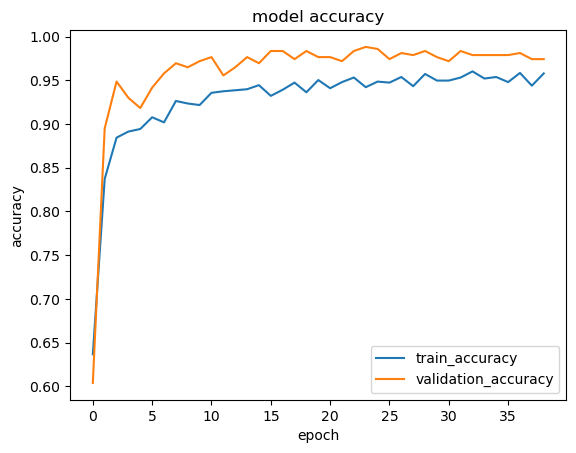

In [122]:
show_history(history_object)


**Get Loss Value And Metrics Values On Validation Dataset**

In [123]:
score = model.evaluate(x_valid, y_valid, verbose=0)
print('Validation loss:', score[0])
print('Validation accuracy:', score[1])
 
print('Saving the validation data set...')
 
print('Length of the validation data set:', len(x_valid))


Validation loss: 0.06575595587491989
Validation accuracy: 0.9743589758872986
Saving the validation data set...
Length of the validation data set: 429


**Evaluate Model**

In [124]:
# Go through the validation data set, and see how the model did on each image
for idx in range(len(x_valid)):
 
  # Make the image a NumPy array
  img_as_ar = np.array([x_valid[idx]])
 
  # Generate predictions    
  prediction = model.predict(img_as_ar)
 
  # Determine what the label is based on the highest probability
  label = np.argmax(prediction)
 
  # Create the name of the directory and the file for the validation data set
  # After each run, delete this out_valid/ directory so that old files are not
  # hanging around in there.
  file_name = str(idx) + "_" + str(label) + "_" + str(np.argmax(str(y_valid[idx]))) + ".jpg"
  img = img_as_ar[0]
 
  # Reverse the image preprocessing process
  img = reverse_preprocess_inception(img)
 
  # Save the image file
  cv2.imwrite(file_name, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
 
print('The validation data set has been saved!')


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 